<a href="https://colab.research.google.com/github/marcopeduto/marcopeduto/blob/main/Labo_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import collections  as mc
%load_ext autoreload
%autoreload 2
import pandas as pd
import seaborn as sns
# sklearn imports
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
sns.set_style("white")

# set random seed
np.random.seed(72)

In [ ]:
#donné

#Load data
# data-set: heart.csv
url = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/heart.csv"
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,target
0,63,M,D,145,233,yes,A,150,no,1
1,37,M,C,130,250,no,B,187,no,1
2,41,F,B,130,204,no,A,172,no,1
3,56,M,B,120,236,no,B,178,no,1
4,57,F,A,120,354,no,B,163,yes,1


In [ ]:
X = df[['age', 'thalach']]
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=72
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Créer et ajuster le scaler sur les données d'entraînement
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# Définir le modèle
model = LogisticRegressionCV(
    solver='lbfgs',
    cv=10,
    max_iter=100,
    random_state=72
)

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegressionCV(cv=10, random_state=72)

In [ ]:
# Accuracy sur le set d'entraînement
train_accuracy = model.score(X_train_scaled, y_train)
print("Train Accuracy:", train_accuracy)

# Accuracy sur le set de test
test_accuracy = model.score(X_test_scaled, y_test)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.6886792452830188
Test Accuracy: 0.7142857142857143


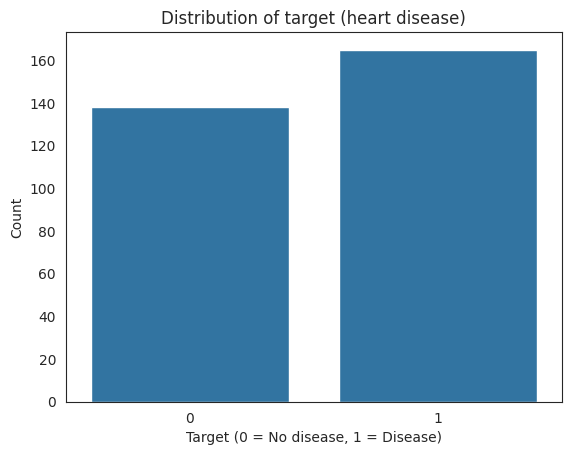

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar chart pour visualiser la distribution de la variable cible
sns.countplot(x=y)
plt.title("Distribution of target (heart disease)")
plt.xlabel("Target (0 = No disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Nombre d'observations avec maladie cardiaque (target = 1)
nbr_heart_disease = sum(y == 1)
print(f'There are {nbr_heart_disease} observations with heart diseases')

# Nombre d'observations sans maladie cardiaque (target = 0)
nbr_no_heart_disease = sum(y == 0)
print(f'There are {nbr_no_heart_disease} observations with no heart diseases')

# Calcul du base rate (proportion de cas positifs)
base_rate = nbr_heart_disease / len(y)
print(f'The Base rate is : {base_rate:.2f}')

There are 165 observations with heart diseases
There are 138 observations with no heart diseases
The Base rate is : 0.54


In [ ]:
from sklearn.metrics import confusion_matrix

# Prédictions sur le jeu de test
y_test_pred = model.predict(X_test_scaled)

# Générer la matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[25 13]
 [13 40]]


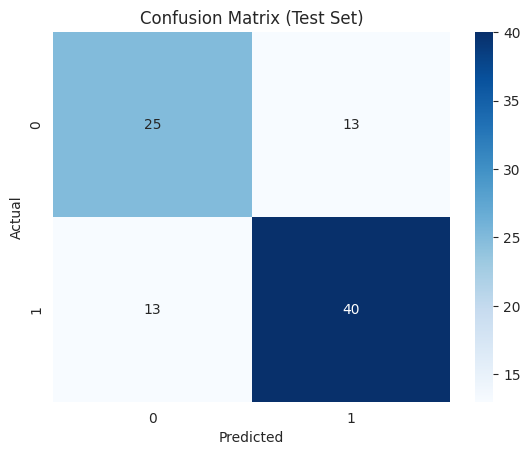

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
features = pd.DataFrame({
    'age': [35, 70],
    'thalach': [160, 130]
})

# Appliquer le scaler entraîné précédemment
features_scaled = scaler.transform(features)

# Prédiction des classes
predictions_q1 = model.predict(features_scaled)
print(f'The first patient has a prediction of {predictions_q1[0]} and the second one {predictions_q1[1]}')

# Probabilités associées aux prédictions
proba_q1 = model.predict_proba(features_scaled)
print(f'The probabilities of the first patient are {proba_q1[0]} and {proba_q1[1]} for the second')

The first patient has a prediction of 1 and the second one 0
The probabilities of the first patient are [0.31765375 0.68234625] and [0.69527813 0.30472187] for the second


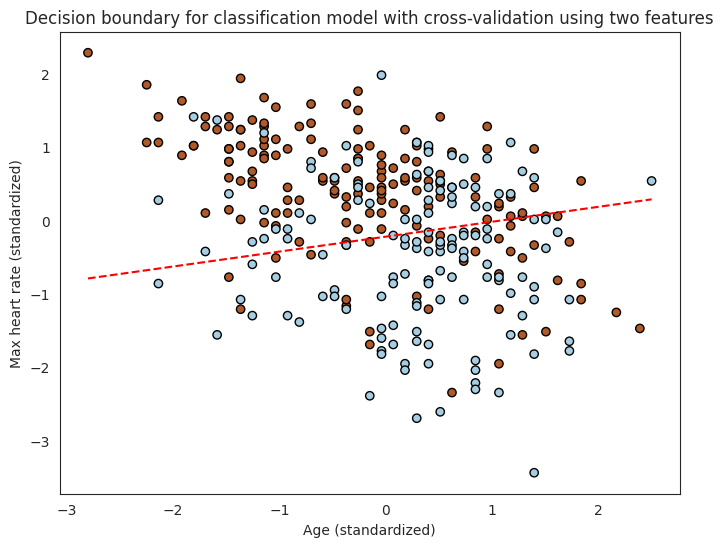

In [ ]:
# On sélectionne les deux variables
X_all = df[['age', 'thalach']]
y_all = df['target']

# Standardisation sur toutes les données
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# Modèle de régression logistique avec validation croisée
model_all = LogisticRegressionCV(
    solver='lbfgs',
    cv=10,
    max_iter=100,
    random_state=72
)
model_all.fit(X_all_scaled, y_all)

# Tracer les points
plt.figure(figsize=(8, 6))
plt.scatter(X_all_scaled[:, 0], X_all_scaled[:, 1], c=y_all, edgecolors='k', cmap=plt.cm.Paired)

# Tracer la frontière de décision
ax = plt.gca()
x_vals = np.linspace(X_all_scaled[:, 0].min(), X_all_scaled[:, 0].max(), 200)
# Calcul de la frontière à partir des coefficients du modèle : coef_ = [w1, w2], intercept = b
# L'équation de la frontière de décision : w1*x + w2*y + b = 0  => y = -(w1*x + b)/w2
y_vals = -(model_all.coef_[0][0] * x_vals + model_all.intercept_[0]) / model_all.coef_[0][1]
plt.plot(x_vals, y_vals, '--', c='red')

plt.xlabel('Age (standardized)')
plt.ylabel('Max heart rate (standardized)')
plt.title('Decision boundary for classification model with cross-validation using two features')
plt.show()


In [ ]:
X = df[['age', 'thalach', 'trestbps', 'chol']]
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=72)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegressionCV(solver='lbfgs', cv=10, max_iter=100, random_state=72)
model.fit(X_train_scaled, y_train)

LogisticRegressionCV(cv=10, random_state=72)

In [ ]:
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)
print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Train Accuracy: 0.7170
Test Accuracy: 0.7033


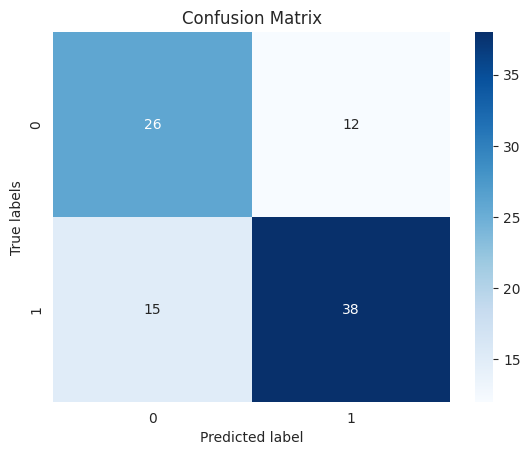

In [ ]:
cm = confusion_matrix(y_test, model.predict(X_test_scaled))
sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='.4g')
plt.xlabel('Predicted label')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Moodle question 1

import numpy as np

# Supposons que la matrice de confusion soit la suivante (valeurs à ajuster selon le cas)
# Remplis la matrice de confusion selon les valeurs spécifiques que tu as obtenues
confusion_matrix = np.array([[4, 1],  # True class 0: 4 correct predictions, 1 wrong prediction
                             [5, 5]]) # True class 1: 5 correct predictions, 5 wrong predictions

# Calcul de l'accuracy
# La précision est le nombre total de bonnes prédictions divisé par le nombre total de prédictions
accuracy = np.trace(confusion_matrix) / np.sum(confusion_matrix)

# Affichage de la précision
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 60.00%


In [ ]:
#Moodle question 2

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

# Chargement des données (assurez-vous d'avoir déjà chargé le dataset dans df)
url = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/heart.csv"
df = pd.read_csv(url)

# Sélection des caractéristiques (features) et de la variable cible (target)
X = df[['age', 'thalach']]
y = df['target']

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entraînement du modèle de régression logistique avec cross-validation
model = LogisticRegressionCV(solver='lbfgs', cv=10, max_iter=100, random_state=72)
model.fit(X_scaled, y)

# Définir les caractéristiques des deux patients
patients = pd.DataFrame({
    'age': [35, 70],
    'thalach': [160, 130]
})

# Standardiser les données des patients
patients_scaled = scaler.transform(patients)

# Prédiction de la classe pour chaque patient
predictions = model.predict(patients_scaled)

# Affichage des résultats
for i, prediction in enumerate(predictions, 1):
    heart_disease = "has heart disease" if prediction == 1 else "does not have heart disease"
    print(f"Patient {i}: {heart_disease}")


Patient 1: has heart disease
Patient 2: does not have heart disease
